# On-Device Training - Plots

In [1]:
import math, copy, os, glob, random, sys, json, torch, numpy as np, matplotlib.pyplot as plt, pandas as pd
from torch.utils.data import DataLoader, sampler, Subset
sys.path.append("../../dataset/")
from dataset import EEGDataset2DLeftRight, EEGDataset2DLeftRightRestFeet, ToTensor
from utility import train_validate_split_5_fold_CV, sample_single_class_indices
from datetime import datetime
from matplotlib.gridspec import GridSpec
sys.path.append("../../src/models/")
from snn import WrapCUBASpikingCNN as WrapSNN2C
from matplotlib.ticker import FuncFormatter

def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [2]:
seed=5
set_global_seed(seed)

spike_ts   = 160
BATCH_SIZE = 64
CDECAY   = 0.1
VDECAY   = 0.1
VTH      = 0.1
GRAD_WIN = 0.3
TH_AMP   = 0.01
TH_DECAY = 0.1
BASE_TH  = 0.01
param_list = [CDECAY, VDECAY, VTH, GRAD_WIN, TH_AMP, TH_DECAY, BASE_TH]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
def collect_weights(model, layerwise = False):
    """
    If layerwise=True, returns 1D CPU tensor of that layer's weights.

    Else returns a single concatenated 1D CPU tensor (all *.weight).

    :param model: PyTorch model whose parameters will be inspected or modified.
    :param layerwise: If True, return a dict per layer; if False, concatenate all weights into one 1D tensor.
    :return: If layerwise is True, a dict mapping parameter names to 1D CPU tensors; otherwise a single concatenated 1D CPU tensor of all weights.
    """
    parts = {
        n: p.detach().reshape(-1).cpu()
        for n, p in model.named_parameters()
        if n.endswith(".weight")
    }
    if layerwise:
        return parts
    return torch.cat(list(parts.values()))

## Functions

In [4]:
def load_finetune_folds_for_config(thr=0.025,thr_asym=1.0, base_dir="snn_experiment_results/model_online",
                                    n_folds=1, dut="dut2", A_scale=1.0, A_asym=1.0,
                                    rsd_c2c=0.0, q=0, mode="samples",):
    """
    Load finetuning accuracy logs for multiple folds

    :param thr: minimum threshold value
    :param thr_asym: asymmetric factor for thr (LTD)
    :param base_dir: base directory containing the result files
    :param n_folds: number of folds to load
    :param dut: device-under-test identifier in filename
    :param A_scale: amplitude scaling factor
    :param A_asym: amplitude asymmetry factor
    :param rsd_c2c: cycle-to-cycle RSD value in filename
    :param mode: "samples" for accuracy_per_sample_*.txt,
                 "epochs"  for accuracy_per_epoch_*.txt
    :return: list of pandas.DataFrame, one per fold
    """
    def fmt(val): return str(val).replace(".", "p")

    thr_str  = fmt(thr)
    thr_asym_str = fmt(thr_asym)
    Ascale_str = fmt(A_scale)
    Aasym_str = fmt(A_asym)
    rsd_str = fmt(rsd_c2c)

    # pattern for the file name
    prefix = "accuracy_per_sample" if mode == "samples" else "accuracy_per_epoch"

    # pattern = (
    #     f"{prefix}_seed_5_fold_{{fold}}_dut_{dut}_thr_{thr_str}_thrasym_{thr_asym_str}_"
    #     f"Ascale_{Ascale_str}_Aasym_{Aasym_str}_rsdc2c_{rsd_str}_q_{q}_*.txt"
    # )

    pattern = (
        f"{prefix}_seed_5_fold_{{fold}}_dut_{dut}_thr_{thr_str}_thrasym_{thr_asym_str}_"
        f"Ascale_{Ascale_str}_Aasym_{Aasym_str}_rsdc2c_{rsd_str}_q_{q}_*.txt"
    )

    folds = []
    for fold in range(1, n_folds + 1):
        file_pattern = os.path.join(base_dir, pattern.format(fold=fold))
        files = sorted(glob.glob(file_pattern))
        if not files:
            print(f"[WARN] no log file for fold {fold} (pattern: {file_pattern})")
            continue

        df = pd.read_csv(files[-1])  # last file if multiple
        folds.append(df)

    return folds

In [5]:
def remap_layer(raw_name: str):
    """
    Remap layer.

    :param raw_name: Full parameter name as returned by model.named_parameters().
    :return: Remapped layer group name such as 'Conv1', 'Conv2', 'Conv3', 'TC', 'Rec', 'Fc1', 'Fc2', or None if no mapping applies.
    """
    n = raw_name
    if n.endswith(".weight"):
        n = n[:-7]
    n = n.lower()

    # main convs (exclude temporal/tc)
    if ("conv1" in n) and ("temp_conv" not in n) and ("tc" not in n):
        return "Conv1"
    if ("conv2" in n) and ("temp_conv" not in n) and ("tc" not in n):
        return "Conv2"
    if ("conv3" in n) and ("temp_conv" not in n) and ("tc" not in n):
        return "Conv3"

    # temporal conv / TC blocks (pooled)
    if ("temp_conv" in n) or ("tc1" in n) or ("tc2" in n) or ("tc3" in n) or (".tc" in n):
        return "TC"

    # recurrent block
    if ("rec" in n) or (".r1" in n) or ("rec1" in n):
        return "Rec"

    # fully connected
    if ("fc1" in n) or (".f1" in n):
        return "Fc1"
    if ("fc2" in n) or (".f2" in n):
        return "Fc2"

    return None

def group_layer_weights(model, groups=None):
    """
    Collect weights from a model and group them according to remap_layer.

    :param model: PyTorch model whose parameters will be grouped.
    :param groups: Optional iterable of group names to keep; by default
                   uses ["Conv1","Conv2","Conv3","TC","Rec","Fc1","Fc2"].
    :return: dict mapping group_name -> 1D numpy array of concatenated weights.
    """
    if groups is None:
        groups = ["Conv1", "Conv2", "Conv3", "TC", "Rec", "Fc1", "Fc2"]

    W = collect_weights(model, layerwise=True)  # dict: full_name -> tensor

    grouped_lists = {g: [] for g in groups}
    for full_name, w in W.items():
        g = remap_layer(full_name)
        if (g is None) or (g not in grouped_lists):
            continue
        grouped_lists[g].append(w.detach().cpu().numpy().ravel())

    # Concatenate and keep only non-empty groups
    grouped = {g: np.concatenate(v) for g, v in grouped_lists.items() if len(v) > 0}
    return grouped

In [6]:
def aggregate_by_step_over_folds(fold_dfs, val_col="Val_Accuracy", x_col="SamplesSeen"):
    """
    Aggregate accuracy over folds at each logging step

    :param fold_dfs: list of DataFrames (one per fold) with columns:
                     - x_col (e.g. "SamplesSeen" or "Epoch")
                     - val_col (e.g. "Val_Accuracy")
                     All DataFrames must have the same number of rows
    :param val_col: name of the accuracy column to aggregate
    :param x_col: name of the x-axis column ("SamplesSeen" or "Epoch")
    :return: (x_points, mean_acc, std_acc) as numpy arrays
    """
    n_folds = len(fold_dfs)
    assert n_folds > 0, "No folds provided"

    n_steps = len(fold_dfs[0])
    for df in fold_dfs[1:]:
        assert len(df) == n_steps, "All folds must have same number of steps"

    x_points, mean_acc, std_acc = [], [], []

    for k in range(n_steps):
        xs, accs = [], []
        for df in fold_dfs:
            xs.append(df.iloc[k][x_col])
            accs.append(df.iloc[k][val_col] * 100.0)  # convert to %
        xs = np.asarray(xs, dtype=float)
        accs = np.asarray(accs, dtype=float)
        x_val = xs[0] if np.allclose(xs, xs[0]) else float(np.floor(xs.mean()))
        x_points.append(x_val)
        mean_acc.append(accs.mean())
        std_acc.append(accs.std())

    return np.asarray(x_points), np.asarray(mean_acc), np.asarray(std_acc)


In [7]:
def make_counter_global(df, col="LTP_crossings", epoch_col="Epoch", x_col="SamplesSeen"):
    """
    Convert a per-epoch cumulative counter into a global cumulative counter

    The input column `col` is assumed to be cumulative within each epoch
    (starting at 0 at the beginning of an epoch). This function computes the
    per-step increments and then accumulates them across all epochs

    :param df: input DataFrame with at least [epoch_col, x_col, col]
    :param col: name of the per-epoch cumulative counter column
                (e.g. "LTP_crossings" or "LTD_crossings")
    :param epoch_col: name of the epoch column (default: "Epoch")
    :param x_col: name of the x-axis column used for sorting
                  (default: "SamplesSeen")
    :return: DataFrame with an added column f"{col}_global"
    """
    df = df.sort_values([epoch_col, x_col]).copy()

    # per-step increments: within each epoch, diff; first row uses original value
    delta = df.groupby(epoch_col)[col].diff().fillna(df[col])

    # global cumulative sum over all epochs
    df[f"{col}_global"] = delta.cumsum()
    return df


In [16]:
os.makedirs("../../results/postprocessing", exist_ok=True)
os.makedirs("../../results/figures", exist_ok=True)

In [8]:
def plot_accuracy_sweep(sweep_values, base_dir, n_folds=5, mode="samples", val_col="Val_Accuracy",
                        print_col="Test_Accuracy", save_path=None, sweep_param="thr", fixed_config=None):
    """
    Plot validation accuracy vs samples or epochs for a sweep over one config parameter

    :param sweep_values: list of values for the swept parameter (e.g. thr, thr_asym, rsdc2c)
    :param base_dir: base directory containing the result files
    :param n_folds: number of folds to average over
    :param mode: "samples" for per-sample logs (x = SamplesSeen),
                 "epochs"  for per-epoch logs (x = Epoch)
    :param val_col: name of the accuracy column to plot (e.g. "Val_Accuracy")
    :param print_col: name of the accuracy column to print final mean/std for
                      (e.g. "Test_Accuracy")
    :param save_path: optional path to save the figure; if None, do not save
    :param sweep_param: name of the parameter to sweep (must match the argument
                        name in load_finetune_folds_for_config, e.g. "thr",
                        "thr_asym", "rsdc2c")
    :param fixed_config: optional dict of other fixed config parameters passed
                         to load_finetune_folds_for_config (e.g. {"rsdc2c": 0.05})
    :return: (fig, ax) matplotlib objects
    """
    assert mode in ("samples", "epochs")

    x_col   = "SamplesSeen" if mode == "samples" else "Epoch"
    x_label = "Sample" if mode == "samples" else "Epoch"
    x_slice = slice(1, None) if mode == "samples" else slice(None)

    if fixed_config is None:
        fixed_config = {}

    plt.rcParams.update({"font.size": 14})
    fig, ax = plt.subplots(figsize=(4, 3))

    markers = ["o", "s", "D"]
    i = 0

    for val in sweep_values:
        # build kwargs for the loader: swept param + any fixed config
        cfg = dict(fixed_config)
        cfg[sweep_param] = val
        print(cfg)

        fold_dfs = load_finetune_folds_for_config(base_dir=base_dir, n_folds=n_folds, mode=mode, **cfg)
        if not fold_dfs:
            continue

        # validation accuracy for plotting
        x_vals, mean_val, std_val = aggregate_by_step_over_folds(fold_dfs, val_col=val_col, x_col=x_col)

        x_plot    = x_vals[x_slice]
        mean_plot = mean_val[x_slice]
        std_plot  = std_val[x_slice]

        df = pd.DataFrame({
        "x_plot": x_plot,
        "mean_plot": mean_plot,
        "std_plot": std_plot,
        })
        df.to_csv(f"../../results/postprocessing/plot_sweep_{sweep_param}_{val}.csv", index=False)

        marker = markers[i]
        if sweep_param == "thr_asym":
            label = f"{val}"
        elif sweep_param == "q" and val == 0:
            label = "no re-quant"
        elif sweep_param == "q":
            label = f"{val+1}"
        elif sweep_param == "rsdc2c":
            label = f"{val*100:.0f}"
        else:
            label = f"{val*100}"
        ax.errorbar(x_plot, mean_plot, yerr=std_plot, marker=marker,
                    markerfacecolor="none", capsize=3, linewidth=1.5, label=label)
        i += 1

        # test accuracy for printing only
        _, mean_test, std_test = aggregate_by_step_over_folds(fold_dfs, val_col=print_col, x_col=x_col)
        mean_test_plot = mean_test[x_slice]
        std_test_plot  = std_test[x_slice]

        final_mean_test = mean_test_plot[-1]
        final_std_test  = std_test_plot[-1]
        print(f"{sweep_param}={val}: mode={mode}, final {print_col} = {final_mean_test:.2f}% ± {final_std_test:.2f}%")

    ax.set_xlabel(x_label)
    ax.set_ylabel("Accuracy (%)")

    if sweep_param == "thr":
        legend_title = r"$\epsilon$ (%)"
    elif sweep_param == "thr_asym":
        legend_title = r"$\epsilon_{\mathrm{asym}}$"
    elif sweep_param == "q":
        legend_title = "q"
    elif sweep_param == "rsdc2c":
        legend_title = "RSD (%)"
    else:
        legend_title = f"{sweep_param} (%)"
    ax.grid(True)
    ax.legend(title=legend_title, loc="lower right" if sweep_param != "q" else "center right")

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
    plt.show()

    return fig, ax


In [9]:
def plot_pretrain_quant_finetune_over_epochs(pre_pattern, ft_pattern, n_folds=1, save_path=None, x=4.0, epochs = 4):
    """
    Plot pretraining and finetuning accuracy over epochs, including quant+noise drop

    :param pre_pattern: glob pattern for pretraining log files with '{fold}' placeholder
                        (e.g. "snn_experiment_results/pretrained_model_5_fold_final/transfer_learning_pretraining_accuracy_over_samples_seed_5_fold_{fold}_*.txt")
    :param ft_pattern: glob pattern for finetuning log files with '{fold}' placeholder
                       (e.g. "snn_experiment_results/finetuned_model_5_fold_all_layers_model_final_dut2/RSD_2.0/accuracy_over_samples_seed_5_fold_{fold}_dWmin_0p05_dWasym_1p0_Ascale_1p0_Aasym_1p0_sigmabounds_0p0_*.txt")
    :param n_folds: number of folds to load and aggregate
    :param save_path: optional path to save the figure; if None, do not save
    :return: (fig, ax) matplotlib objects
    """
    pre_folds = []
    ft_folds_epochs = []
    ft_folds_full = []

    for fold in range(1, n_folds + 1):
        # --- pretraining ---
        pre_files = sorted(glob.glob(pre_pattern.format(x=x, fold=fold)))
        if not pre_files:
            print(f"[WARN] no pre file for fold {fold}")
            continue

        df_pre = pd.read_csv(pre_files[-1])
        df_pre = df_pre[df_pre["Phase"] == "pretrain"].copy()
        df_pre = df_pre.sort_values(["Epoch", "SamplesSeen"])
        # keep only last log entry per epoch
        df_pre = df_pre.groupby("Epoch", as_index=False).tail(1).reset_index(drop=True)
        pre_folds.append(df_pre)

        # --- finetuning ---
        ft_files = sorted(glob.glob(ft_pattern.format(x=x, epochs = epochs, fold=fold)))
        if not ft_files:
            print(f"[WARN] no finetune file for fold {fold}")
            continue

        df_ft = pd.read_csv(ft_files[-1])
        df_ft = df_ft[df_ft["Phase"] == "finetune"].copy()
        df_ft = df_ft.sort_values(["Epoch", "SamplesSeen"])
        ft_folds_full.append(df_ft)

        # end-of-epoch values for finetuning curve
        df_ft_epoch = df_ft.groupby("Epoch", as_index=False).tail(1).reset_index(drop=True)
        ft_folds_epochs.append(df_ft_epoch)

    print(f"Loaded {len(pre_folds)} pre folds and {len(ft_folds_epochs)} finetune folds")

    if not pre_folds or not ft_folds_epochs:
        print("[ERROR] no folds loaded, aborting plot")
        return None, None

    # ---------- aggregate over folds (epoch domain) ----------
    # pretraining (Epoch 1..20)
    x_pre, mean_pre, std_pre = aggregate_by_step_over_folds(pre_folds, val_col="Val_Accuracy", x_col="Epoch")

    # finetuning over epochs (raw epochs 1..2)
    x_ft_ep, mean_ft_ep, std_ft_ep = aggregate_by_step_over_folds(ft_folds_epochs, val_col="Val_Accuracy", x_col="Epoch")

    # ---------- quant+noise point from finetune step 0 (per-sample logs) ----------
    # use full finetune logs and SamplesSeen to get the very first "quant+noise" accuracy
    _, mean_ft_full, std_ft_full = aggregate_by_step_over_folds(ft_folds_full, val_col="Val_Accuracy", x_col="SamplesSeen")
    q_acc_mean = mean_ft_full[0]
    q_acc_std  = std_ft_full[0]

    # ---------- build global epoch axis ----------
    # last pretraining epoch (should be 20)
    x_pre_end = x_pre[-1]

    # shift finetuning epochs so they continue after pretraining (e.g. 21, 22)
    x_ft_global = x_pre_end + x_ft_ep

    # EXCLUDE the first finetune point from the plotted curve
    x_ft_plot    = x_ft_global[1:]
    mean_ft_plot = mean_ft_ep[1:]
    std_ft_plot  = std_ft_ep[1:]

    # pretrain data
    df_pre = pd.DataFrame({
        "x_pre": x_pre,
        "mean_pre": mean_pre,
        "std_pre": std_pre,
    })
    df_pre.to_csv(f"../../results/postprocessing/plot_finetune_pre_x_{x}.csv", index=False)

    # finetune data (global epochs)
    df_ft = pd.DataFrame({
        "x_ft_plot": x_ft_plot,
        "mean_ft_plot": mean_ft_plot,
        "std_ft_plot": std_ft_plot,
    })
    df_ft.to_csv(f"../../results/postprocessing/plot_finetune_ft_x_{x}.csv", index=False)

    # quant+noise point as a tiny 1-row CSV if you want that too:
    df_q = pd.DataFrame({
        "x_pre_end": [x_pre_end],
        "q_acc_mean": [q_acc_mean],
    })
    df_q.to_csv(f"../../results/postprocessing/plot_finetune_quant_x_{x}.csv", index=False)

    # ---------- plot ----------
    plt.rcParams.update({"font.size": 14})
    fig, ax = plt.subplots(figsize=(4, 3))

    # pretraining curve
    ax.errorbar(x_pre, mean_pre, yerr=std_pre, marker="o", markerfacecolor="none", capsize=3, linewidth=1.5, label="Pre-training")

    # vertical drop for quant+noise at the boundary epoch
    ax.plot([x_pre_end, x_pre_end], [mean_pre[-1], q_acc_mean], "k--", label="Quant+Noise")

    # connect bottom of the drop to first finetuning point (no marker here)
    ax.plot([x_pre_end, x_ft_plot[0]], [q_acc_mean, mean_ft_plot[0]], color="C1", linewidth=1.5)

    # finetuning recovery curve (starting at next epoch index)
    ax.errorbar(x_ft_plot, mean_ft_plot, yerr=std_ft_plot, marker="s", markerfacecolor="none", capsize=3, linewidth=1.5, label="Re-tuning")

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy (%)")
    ax.grid(True)
    ax.set_title(f"q = 3, $\\eta$={1/x*100}%", fontsize=14)
    ax.legend(loc="lower center")

    plt.tight_layout()
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
    plt.show()

     # ---------- print final finetune test accuracy over folds ----------
    final_tests = []
    for df_ft_ep in ft_folds_epochs:
        # end-of-epoch Test_Accuracy for the last finetune epoch of this fold
        final_tests.append(df_ft_ep["Test_Accuracy"].iloc[-1] * 100.0)

    if final_tests:
        final_tests = np.asarray(final_tests, dtype=float)
        mean_test = final_tests.mean()
        std_test  = final_tests.std()
        print(f"Final finetune test accuracy over folds: {mean_test:.2f}% ± {std_test:.2f}%")
    else:
        print("[WARN] no finetune folds available for test accuracy summary")

    return fig, ax


In [10]:
def plot_weight_histograms_two_models(model_before, model_after, target_group="Conv2", bins=60,
                                      fig_size=(6.67, 3.4), save_path=None):
    """
    Plot weight histograms for a single layer group for two models side by side.

    Left panel:  initial model.
    Right panel: on-device trained model.

    :param model_before: first model (nn.Module) or path to a saved model (.pth).
    :param model_after: second model (nn.Module) or path to a saved model (.pth).
    :param target_group: Group name ("Conv1","Conv2","Conv3","TC","Rec","Fc1","Fc2").
    :param bins: Number of histogram bins.
    :param fig_size: Matplotlib figure size.
    :param save_path: Optional file path to save the figure.
    :return: dict with keys "before" and "after" containing 1D numpy arrays of weights.
    """
    net_before = WrapSNN2C(spike_ts=spike_ts, device=device, param_list=param_list)
    net_after  = WrapSNN2C(spike_ts=spike_ts, device=device, param_list=param_list)
    if isinstance(model_before, (str, os.PathLike)):
        state_before = torch.load(model_before, map_location=device)
        net_before.load_state_dict(state_before)
    if isinstance(model_after, (str, os.PathLike)):
        state_after = torch.load(model_after, map_location=device)
        net_after.load_state_dict(state_after)

    net_before.eval()
    net_after.eval()

    grouped_before = group_layer_weights(net_before, groups=[target_group])
    if target_group not in grouped_before:
        raise ValueError(f"Target group '{target_group}' not found in model_before.")
    w_before = grouped_before[target_group]

    grouped_after = group_layer_weights(net_after, groups=[target_group])
    if target_group not in grouped_after:
        raise ValueError(f"Target group '{target_group}' not found in model_after.")
    w_after = grouped_after[target_group]

    # shared x-range
    all_vals = np.concatenate([w_before, w_after])
    xmin, xmax = np.min(all_vals), np.max(all_vals)

    fig, axes = plt.subplots(1, 2, figsize=fig_size, sharex=True)
    label_fs, tick_fs = 14, 14

    ax = axes[0]
    ax.hist(w_before, bins=bins, alpha=0.8, edgecolor="black")
    ax.set_title("Before on-device training", fontsize=label_fs)
    ax.set_xlabel("Weight value", fontsize=label_fs)
    ax.set_ylabel("Count", fontsize=label_fs)
    ax.tick_params(axis="both", labelsize=tick_fs)
    # ax.set_xlim(xmin, xmax)
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.hist(w_after, bins=bins, alpha=0.8, edgecolor="black")
    ax.set_title("After on-device training", fontsize=label_fs)
    ax.set_xlabel("Weight value", fontsize=label_fs)
    ax.tick_params(axis="both", labelsize=tick_fs)
    # ax.set_xlim(xmin, xmax)
    ax.grid(True, alpha=0.3)

    def weight_tick_formatter(x, pos):
        # show 0 as "0.0", everything else as "%.3f"
        if abs(x) < 1e-8:
            return "0.0"
        return f"{x:.3f}"

    ticks = np.linspace(-0.025, 0.025, 3)  # e.g. [-0.025, 0.0, 0.025]

    for ax in axes:
        ax.set_xticks(ticks)
        ax.xaxis.set_major_formatter(FuncFormatter(weight_tick_formatter))

    plt.suptitle(f"Fold 1 — {target_group} weights", fontsize=label_fs)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)

    plt.show()

    return {"before": w_before, "after": w_after}


In [11]:
def compute_final_test_accuracy_stats_grid(thr_values, thr_asym_values, base_dir="snn_experiment_results/model_online", n_folds=5,
                                        dut="dut2", mode="epochs", A_scale=1.0, A_asym=1.0, rsd_c2c=0.0, q=0, col="Test_Accuracy"):
    """
    Compute mean and std of final test accuracies over all folds
    for each (thr, thr_asym) configuration of a single DUT.

    For each (thr, thr_asym), all folds are loaded via
    `load_finetune_folds_for_config`. From each fold, the last
    value of `col` (default: "Test_Accuracy") is taken. The
    mean and standard deviation over folds are returned.

    :return: (mean_grid, std_grid), each with shape
             (len(thr_asym_values), len(thr_values)).
             Missing configurations are NaN.
    """
    n_y = len(thr_asym_values)
    n_x = len(thr_values)

    mean_grid = np.full((n_y, n_x), np.nan, dtype=float)
    std_grid = np.full((n_y, n_x), np.nan, dtype=float)

    for iy, thr_asym in enumerate(thr_asym_values):
        for ix, thr in enumerate(thr_values):
            fold_dfs = load_finetune_folds_for_config(thr=thr, thr_asym=thr_asym, base_dir=base_dir, n_folds=n_folds,
                                                    dut=dut, A_scale=A_scale, A_asym=A_asym, rsd_c2c=rsd_c2c, q=q, mode=mode)

            if not fold_dfs:
                continue

            final_vals = [df[col].iloc[-1] for df in fold_dfs]
            vals = np.asarray(final_vals, dtype=float)

            mean_grid[iy, ix] = vals.mean()*100
            std_grid[iy, ix] = vals.std()*100

    return mean_grid, std_grid


def plot_final_test_accuracy_heatmap_for_dut(thr_values, thr_asym_values, base_dir="snn_experiment_results/model_online", n_folds=5,
                                            dut="dut2", mode="epochs", A_scale=1.0, A_asym=1.0, rsd_c2c=0.0, q=0, save_path=None):
    """
    Plot a heatmap of the mean final test accuracy vs (thr, thr_asym)
    for a single DUT and show mean ± std in each square.

    X-axis: `thr` values.
    Y-axis: `thr_asym` values.
    Color: mean of the last `Test_Accuracy` over folds.
    Text:  mean ± std over folds.

    :return: (fig, ax, mean_grid, std_grid).
    """
    mean_grid, std_grid = compute_final_test_accuracy_stats_grid(thr_values=thr_values, thr_asym_values=thr_asym_values, base_dir=base_dir, n_folds=n_folds,
                                                                dut=dut, mode=mode, A_scale=A_scale, A_asym=A_asym, rsd_c2c=rsd_c2c, q=q)

    plt.rcParams.update({"font.size": 14})
    fig, ax = plt.subplots(figsize=(4, 3.0))

    vmin = np.nanmin(mean_grid)
    vmax = np.nanmax(mean_grid)
    im = ax.imshow(mean_grid, origin="lower", vmin=vmin, vmax=vmax, cmap="Blues")

    ax.set_xticks(np.arange(len(thr_values)))
    ax.set_xticklabels(thr_values)
    ax.set_yticks(np.arange(len(thr_asym_values)))
    ax.set_yticklabels(thr_asym_values)

    ax.set_xlabel("thr")
    ax.set_ylabel("thr_asym")
    ax.set_title(f"DUT {dut}")

    # mean ± std in each cell
    for iy in range(len(thr_asym_values)):
        for ix in range(len(thr_values)):
            m = mean_grid[iy, ix]
            if np.isnan(m):
                continue
            s = std_grid[iy, ix]
            ax.text(ix, iy, f"{m:.2f}\n±{s:.2f}", ha="center", va="center")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Mean final test accuracy")

    plt.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)

    plt.show()

    return fig, ax, mean_grid, std_grid

In [12]:
def plot_accuracy_vs_updates_sweep(sweep_values, base_dir, n_folds=5, acc_col="Val_Accuracy", counter_cols=("LTP_crossings", "LTD_crossings"),
                                    sweep_param="thr", fixed_config=None, save_path=None):
    """
    Plot accuracy as a function of the total number of weight updates
    (LTP + LTD) for a sweep over one parameter.

    X-axis  = cumulative number of updates (sum of global counters).
    Y-axis  = accuracy (mean ± std over folds).
    One curve per value in `sweep_values` (e.g. three different thresholds).

    :param sweep_values: list of values for the swept parameter (e.g. thr values).
    :param base_dir: base directory containing the result files.
    :param n_folds: number of folds to average over.
    :param acc_col: name of the accuracy column to plot (e.g. "Val_Accuracy").
    :param counter_cols: iterable of per-epoch counter columns to sum
                         (e.g. ("LTP_crossings", "LTD_crossings")).
    :param sweep_param: name of the parameter to sweep (must match the argument
                        name in load_finetune_folds_for_config, e.g. "thr",
                        "thr_asym", "rsdc2c").
    :param fixed_config: optional dict of other fixed config parameters passed
                         to load_finetune_folds_for_config.
    :param save_path: optional path to save the figure; if None, do not save.
    :return: (fig, ax) matplotlib objects.
    """
    if fixed_config is None:
        fixed_config = {}

    plt.rcParams.update({"font.size": 14})
    fig, ax = plt.subplots(figsize=(4, 3))

    # scientific notation on x-axis
    ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))

    markers    = ["o", "s", "D"]
    linestyles = ["-", "--", "-."]
    i = 0

    for val in sweep_values:
        cfg = dict(fixed_config)
        cfg[sweep_param] = val

        # logs must be in "samples" mode because we need per-step counters
        fold_dfs = load_finetune_folds_for_config(
            base_dir=base_dir,
            n_folds=n_folds,
            mode="samples",
            **cfg,
        )
        if not fold_dfs:
            continue

        processed_folds = []
        for df in fold_dfs:
            df = df.sort_values(["Epoch", "SamplesSeen"]).copy()

            total_updates = None
            # make each counter truly global, then sum them
            for col in counter_cols:
                df = make_counter_global(df, col=col)
                glob_col = f"{col}_global"
                if total_updates is None:
                    total_updates = df[glob_col].copy()
                else:
                    total_updates = total_updates + df[glob_col]

            df["updates_global"] = total_updates
            processed_folds.append(df)

        x_vals, mean_acc, std_acc = aggregate_by_step_over_folds(
            processed_folds,
            val_col=acc_col,
            x_col="updates_global",
        )

        marker   = markers[i % len(markers)]
        linestyle = linestyles[i % len(linestyles)]
        i += 1

        df = pd.DataFrame({
        "x_vals": x_vals,
        "mean_acc": mean_acc,
        })
        df.to_csv(f"../../results/postprocessing/plot_updates_acc_{sweep_param}_{val}.csv", index=False)

        # main curve
        ax.plot(
            x_vals, mean_acc,
            label=f"{val*100:g}",
        )

        # shaded ± std band
        # ax.fill_between(
        #     x_vals,
        #     mean_acc - std_acc,
        #     mean_acc + std_acc,
        #     alpha=0.2,
        # )

        print(
            f"{sweep_param}={val}: final {acc_col} at updates={x_vals[-1]:.0f} "
            f"is {mean_acc[-1]:.2f}% ± {std_acc[-1]:.2f}%"
        )

    ax.set_xlabel("Weight updates")
    ax.set_ylabel("Accuracy (%)")
    ax.grid(True)

    legend_map = {"thr": r"$\epsilon$ (%)", "thr_asym": r"$\epsilon_{\mathrm{asym}}$"}
    legend_title = legend_map.get(sweep_param, sweep_param)
    ax.legend(title=legend_title, loc="lower right")

    plt.tight_layout()
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
    plt.show()

    return fig, ax


In [13]:
def plot_finetune_only_over_epochs(ft_pattern, n_folds=1, save_path=None, x=4.0, epochs=4):
    """
    Plot finetuning accuracy over epochs only, without the pretraining curve

    :param ft_pattern: glob pattern for finetuning log files with '{fold}' placeholder
                       (e.g. "snn_experiment_results/retuned_model_5_fold_all_layers_model/x_{x}/epochs_{epochs}/accuracy_per_sample_seed_5_fold_{fold}_dut_dut2_thr_0p025_thrasym_1p0_Ascale_1p0_Aasym_1p0_rsdc2c_0p0_*.txt")
    :param n_folds: number of folds to load and aggregate
    :param save_path: optional path to save the figure; if None, do not save
    :return: (fig, ax) matplotlib objects
    """
    ft_folds_epochs = []

    for fold in range(1, n_folds + 1):
        ft_files = sorted(glob.glob(ft_pattern.format(x=x, epochs=epochs, fold=fold)))
        if not ft_files:
            print(f"[WARN] no finetune file for fold {fold}")
            continue

        df_ft = pd.read_csv(ft_files[-1])
        df_ft = df_ft[df_ft["Phase"] == "finetune"].copy()
        df_ft = df_ft.sort_values(["Epoch", "SamplesSeen"])

        # keep only last log entry per epoch
        df_ft_epoch = df_ft.groupby("Epoch", as_index=False).tail(1).reset_index(drop=True)
        ft_folds_epochs.append(df_ft_epoch)

    print(f"Loaded {len(ft_folds_epochs)} finetune folds")

    if not ft_folds_epochs:
        print("[ERROR] no finetune folds loaded, aborting plot")
        return None, None

    # ---------- aggregate over folds ----------
    x_ft, mean_ft, std_ft = aggregate_by_step_over_folds(
        ft_folds_epochs,
        val_col="Val_Accuracy",
        x_col="Epoch",
    )

    # shift x-axis to start at 20 instead of 0
    x_ft = np.asarray(x_ft) + 20

    # export aggregated data
    df_out = pd.DataFrame({
        "x_ft": x_ft,
        "mean_ft": mean_ft,
        "std_ft": std_ft,
    })
    df_out.to_csv(f"../../results/postprocessing/plot_finetune_only_x_{x}_epochs_{epochs}.csv", index=False)

    # ---------- plot ----------
    plt.rcParams.update({"font.size": 14})
    fig, ax = plt.subplots(figsize=(4, 3))

    ax.errorbar(
        x_ft,
        mean_ft,
        yerr=std_ft,
        marker="s",
        markerfacecolor="none",
        capsize=3,
        color="C1",
        linewidth=1.5,
        label="Re-tuning",
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy (%)")
    ax.grid(True)
    ax.set_title(f"q = 3, $\\eta$={1/x*100}%", fontsize=14)
    ax.legend(loc="lower center")

    plt.tight_layout()
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
    plt.show()

    final_tests = [df["Test_Accuracy"].iloc[-1] * 100.0 for df in ft_folds_epochs]
    final_tests = np.asarray(final_tests, dtype=float)
    print(f"Final finetune test accuracy over folds: {final_tests.mean():.2f}% ± {final_tests.std():.2f}%")

    return fig, ax

## Plots

Loaded 5 pre folds and 5 finetune folds


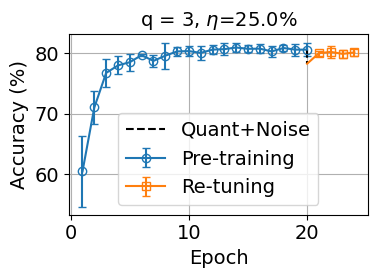

Final finetune test accuracy over folds: 79.08% ± 2.16%


(<Figure size 400x300 with 1 Axes>,
 <Axes: title={'center': 'q = 3, $\\eta$=25.0%'}, xlabel='Epoch', ylabel='Accuracy (%)'>)

In [16]:
x = 4.0
epochs = 4
pre_pattern = "../../snn_experiment_results/pretrained_model_5_fold/transfer_learning_pretraining_accuracy_over_samples_seed_5_fold_{fold}_*.txt"

ft_pattern  = "../../snn_experiment_results/retuned_model_5_fold_all_layers_model/x_{x}/epochs_{epochs}/accuracy_per_sample_seed_5_fold_{fold}_dut_dut2_thr_0p025_thrasym_1p0_Ascale_1p0_Aasym_1p0_rsdc2c_0p0_*.txt"

plot_pretrain_quant_finetune_over_epochs(
    pre_pattern=pre_pattern,
    ft_pattern=ft_pattern,
    n_folds=5,
    save_path=f"../../results/figures/pretrain_finetune_acc_over_epochs_thr_0p025_x_{x}_epochs_{epochs}.svg",
    x = x,
    epochs = epochs,
)

Loaded 5 finetune folds


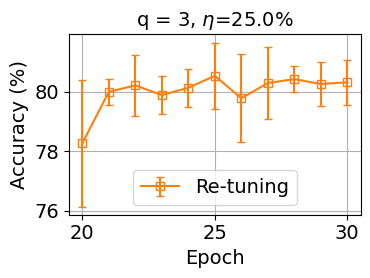

Final finetune test accuracy over folds: 80.46% ± 2.63%


(<Figure size 400x300 with 1 Axes>,
 <Axes: title={'center': 'q = 3, $\\eta$=25.0%'}, xlabel='Epoch', ylabel='Accuracy (%)'>)

In [18]:
x = 4.0
epochs = 10

ft_pattern = ("../../snn_experiment_results/retuned_model_5_fold_all_layers_model/x_{x}/epochs_{epochs}/accuracy_per_sample_seed_5_fold_{fold}_dut_dut2_thr_0p025_thrasym_1p0_Ascale_1p0_Aasym_1p0_rsdc2c_0p0_*.txt")

plot_finetune_only_over_epochs(
    ft_pattern=ft_pattern,
    n_folds=5,
    save_path=f"../../results/figures/finetune_only_acc_over_epochs_thr_0p025_x_{x}_epochs_{epochs}.svg",
    x=x,
    epochs=epochs,
)

{'thr_asym': 0.5}
thr_asym=0.5: mode=epochs, final Test_Accuracy = 79.92% ± 2.50%
{'thr_asym': 1.0}
thr_asym=1.0: mode=epochs, final Test_Accuracy = 79.52% ± 3.15%
{'thr_asym': 2.0}
thr_asym=2.0: mode=epochs, final Test_Accuracy = 78.91% ± 2.76%


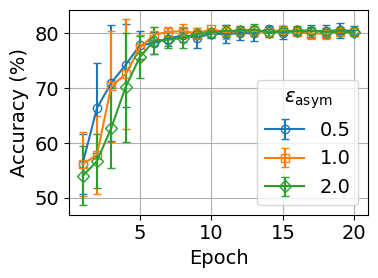

(<Figure size 400x300 with 1 Axes>,
 <Axes: xlabel='Epoch', ylabel='Accuracy (%)'>)

In [19]:
plot_accuracy_sweep(
    sweep_values=[0.5, 1.0, 2.0],
    base_dir="../../snn_experiment_results/model_on_device_5_fold",
    n_folds=5,
    mode="epochs",
    val_col="Val_Accuracy",
    print_col="Test_Accuracy",
    sweep_param="thr_asym",
    save_path="../../results/figures/model_online_thr_asym_sweep.svg",
)

{'thr': 0.025}
thr=0.025: mode=epochs, final Test_Accuracy = 79.52% ± 3.15%
{'thr': 0.05}
thr=0.05: mode=epochs, final Test_Accuracy = 79.13% ± 2.10%
{'thr': 0.075}
thr=0.075: mode=epochs, final Test_Accuracy = 78.91% ± 2.00%


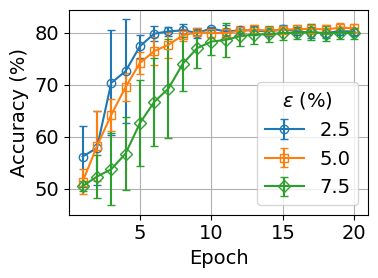

(<Figure size 400x300 with 1 Axes>,
 <Axes: xlabel='Epoch', ylabel='Accuracy (%)'>)

In [20]:
plot_accuracy_sweep(
    sweep_values=[0.025, 0.05, 0.075],
    base_dir="../../snn_experiment_results/model_on_device_5_fold",
    n_folds=5,
    mode="epochs",
    val_col="Val_Accuracy",
    print_col="Test_Accuracy",
    sweep_param="thr",
    save_path="../../results/figures/model_online_thr_sweep.svg",
)

{'q': 0}
q=0: mode=epochs, final Test_Accuracy = 79.52% ± 3.15%
{'q': 2}
q=2: mode=epochs, final Test_Accuracy = 51.31% ± 1.40%
{'q': 4}
q=4: mode=epochs, final Test_Accuracy = 77.34% ± 3.80%


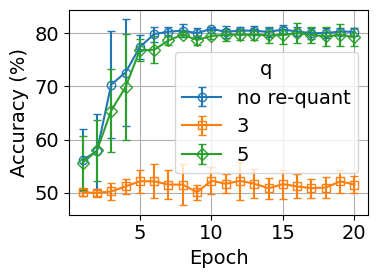

(<Figure size 400x300 with 1 Axes>,
 <Axes: xlabel='Epoch', ylabel='Accuracy (%)'>)

In [21]:
plot_accuracy_sweep(
    sweep_values=[0, 2, 4],
    base_dir="../../snn_experiment_results/model_on_device_5_fold",
    n_folds=5,
    mode="epochs",
    val_col="Val_Accuracy",
    print_col="Test_Accuracy",
    sweep_param="q",
    save_path="../../results/figures/model_online_q_sweep.svg",
)

thr=0.025: final crossings_global=448798
thr=0.05: final crossings_global=230364
thr=0.075: final crossings_global=130705


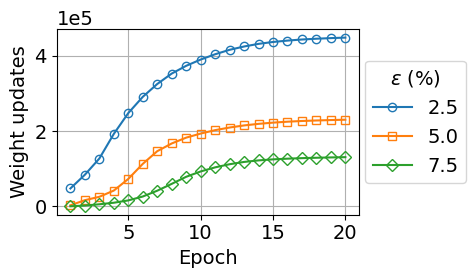

In [22]:
plt.rcParams.update({"font.size": 14})
fig, ax = plt.subplots(figsize=(5, 3))

thr_list = [0.025, 0.05, 0.075]

# scientific notation on y-axis
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

markers = ["o", "s", "D"]
i = 0

for thr in thr_list:
    fold_dfs = load_finetune_folds_for_config(thr=thr, base_dir="../../snn_experiment_results/model_on_device_5_fold", n_folds=5, mode="samples")
    if not fold_dfs:
        continue

    fold_dfs = [make_counter_global(df, col="LTP_crossings") for df in fold_dfs]
    fold_dfs2 = [make_counter_global(df, col="LTD_crossings") for df in fold_dfs]

    fold_dfs_epoch = [
        df.groupby("Epoch", as_index=False).tail(1).reset_index(drop=True)
        for df in fold_dfs
    ]

    fold_dfs2_epoch = [
        df.groupby("Epoch", as_index=False).tail(1).reset_index(drop=True)
        for df in fold_dfs2
    ]

    x_vals, mean_ltp, std_ltp = aggregate_by_step_over_folds(
        fold_dfs_epoch,
        val_col="LTP_crossings_global",
        x_col="Epoch",
    )

    x_vals2, mean_ltp2, std_ltp2 = aggregate_by_step_over_folds(
        fold_dfs2_epoch,
        val_col="LTD_crossings_global",
        x_col="Epoch",
    )

    x_plot    = x_vals[:]       # epochs
    mean_plot = (mean_ltp[:] + mean_ltp2[:])/100.0     # counts
    std_plot  = (std_ltp[:] + std_ltp2[:])/100.0

    df = pd.DataFrame({
    "x_plot": x_plot,
    "mean_plot": mean_plot,
    "std_plot": std_plot,
    })
    df.to_csv(f"../../results/postprocessing/plot_updates_thr_{thr}.csv", index=False)

    marker = markers[i]
    ax.errorbar(x_plot, mean_plot, capsize=3, marker=marker, markerfacecolor="none", linewidth=1.5, label=f"{thr*100}")
    i += 1

    print(f"thr={thr}: final crossings_global={mean_plot[-1]:.0f}")

ax.set_xlabel("Epoch")
ax.set_ylabel("Weight updates")
ax.grid(True)
ax.legend(title=r"$\epsilon$ (%)", bbox_to_anchor=(1.02, 0.5), loc="center left", borderaxespad=0.0)

plt.tight_layout()
plt.savefig("../../results/figures/updates_over_epochs_model_online_thr_sweep.svg")
plt.show()


thr=0.025: final crossings_global=396586


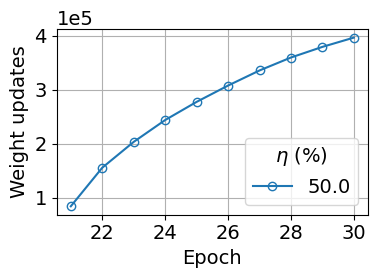

In [23]:
plt.rcParams.update({"font.size": 14})
fig, ax = plt.subplots(figsize=(4, 3))

# scientific notation on y-axis
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

marker = "o"
x = 2.0
epochs = 10
thr = 0.025

fold_dfs = load_finetune_folds_for_config(thr=thr, base_dir=f"../../snn_experiment_results/retuned_model_5_fold_all_layers_model/x_{x}/epochs_{epochs}", n_folds=5, mode="samples")

fold_dfs = [make_counter_global(df, col="LTP_crossings") for df in fold_dfs]
fold_dfs2 = [make_counter_global(df, col="LTD_crossings") for df in fold_dfs]

fold_dfs_epoch = [
    df.groupby("Epoch", as_index=False).tail(1).reset_index(drop=True)
    for df in fold_dfs
]

fold_dfs2_epoch = [
    df.groupby("Epoch", as_index=False).tail(1).reset_index(drop=True)
    for df in fold_dfs2
]

x_vals, mean_ltp, std_ltp = aggregate_by_step_over_folds(
    fold_dfs_epoch,
    val_col="LTP_crossings_global",
    x_col="Epoch",
)

x_vals2, mean_ltp2, std_ltp2 = aggregate_by_step_over_folds(
    fold_dfs2_epoch,
    val_col="LTD_crossings_global",
    x_col="Epoch",
)

x_plot    = x_vals[:] + 20      # epochs
mean_plot = (mean_ltp[:] + mean_ltp2[:])/100.0     # counts
std_plot  = (std_ltp[:] + std_ltp2[:])/100.0

df = pd.DataFrame({
"x_plot": x_plot,
"mean_plot": mean_plot,
"std_plot": std_plot,
})
df.to_csv(f"../../results/postprocessing/plot_updates_finetuning.csv", index=False)

ax.errorbar(x_plot, mean_plot, capsize=3, marker=marker, markerfacecolor="none", linewidth=1.5, label=f"{1/x*100}")

print(f"thr={thr}: final crossings_global={mean_plot[-1]:.0f}")

ax.set_xlabel("Epoch")
ax.set_ylabel("Weight updates")
ax.grid(True)
ax.legend(title=r"$\eta$ (%)", loc="lower right")

plt.tight_layout()
plt.savefig(f"../../results/figures/updates_over_epochs_finetuning_eta_{(1/x)*100}.svg")
plt.show()


thr=0.025: final Val_Accuracy at updates=448797 is 80.24% ± 0.75%
thr=0.05: final Val_Accuracy at updates=230363 is 80.86% ± 0.79%
thr=0.075: final Val_Accuracy at updates=130704 is 79.89% ± 1.07%


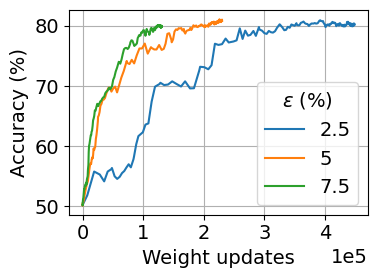

(<Figure size 400x300 with 1 Axes>,
 <Axes: xlabel='Weight updates', ylabel='Accuracy (%)'>)

In [24]:
thr_list = [0.025, 0.05, 0.075]

plot_accuracy_vs_updates_sweep(
    sweep_values=thr_list,
    base_dir="../../snn_experiment_results/model_on_device_5_fold",
    n_folds=5,
    acc_col="Val_Accuracy",
    counter_cols=("LTP_crossings", "LTD_crossings"),
    sweep_param="thr",
    save_path="../../results/figures/acc_vs_total_updates_thr_sweep_no_shades.svg",
)


{'thr': 0.025, 'rsd_c2c': 0.0}
rsd_c2c=0.0: mode=epochs, final Test_Accuracy = 79.52% ± 3.15%
{'thr': 0.025, 'rsd_c2c': 0.05}
rsd_c2c=0.05: mode=epochs, final Test_Accuracy = 79.60% ± 2.92%


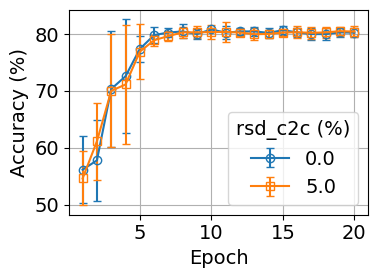

(<Figure size 400x300 with 1 Axes>,
 <Axes: xlabel='Epoch', ylabel='Accuracy (%)'>)

In [25]:
plot_accuracy_sweep(
    sweep_values=[0.0, 0.05],  # baseline vs comparison
    base_dir="../../snn_experiment_results/model_on_device_5_fold",
    n_folds=5,
    mode="epochs",
    val_col="Val_Accuracy",
    print_col="Test_Accuracy",
    sweep_param="rsd_c2c",
    fixed_config={"thr": 0.025},
    save_path="../../results/figures/model_online_thr_0p025_rsd_sweep.svg",
)